# Feature Importance - Klassifikation (t0 vs t5)

Permutation Importance unter LOSO Nested CV mit Baseline Normalisierung.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.myml import extract_signal_from_featurename, loso_binary_nested_cv_with_group_importance, make_signal_groups,loso_binary_nested_cv
from scripts.feature_engeneering import subject_baseline_normalization
from sklearn.ensemble import RandomForestClassifier

### Daten Laden

In [ ]:
DATASET_PATH = Path("dataset/np-dataset")
X = np.load(DATASET_PATH / "X.npy")
X_catch22 = np.load(DATASET_PATH / "X_catch22.npy")
X_catch22_feature_names = np.load(DATASET_PATH / "feature_names.npy")
y_heater = np.load(DATASET_PATH / "y_heater.npy")
subjects = np.load(DATASET_PATH / "subjects.npy")
y = np.argmax(y_heater, axis=1)

# EMG sensor bei 42 war defekt
valid = subjects != 42
X_catch22 = X_catch22[valid]
y = y[valid]
subjects = subjects[valid]

In [4]:
print(f"X shape : {X_catch22.shape}")
print(f"y shape : {y.shape}   classes: {np.unique(y).tolist()}")
print(f"subjects : {np.unique(subjects).shape[0]} unique subjects")
print(f"Feature names : {X_catch22_feature_names.shape[0]}")

X shape : (2495, 174)
y shape : (2495,)   classes: [0, 1, 2, 3, 4, 5]
subjects : 52 unique subjects
Feature names : 174


### Hyperparameter Grid

In [5]:
PARAM_GRID_RF = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

INNER_N_SPLITS = 5
RANDOM_STATE = 42
N_REPEATS = 10
PERM_SCORING = 'roc_auc'

### Daten Vorbereitung

Baseline Normalisierung (t0 als Baseline) und Filterung auf t0 vs t5.

In [ ]:
baseline_class = 0
X_catch22_normalized = subject_baseline_normalization(X_catch22, y, subjects, baseline_class)

class_comparison = (0, 5)
mask = (y == class_comparison[0]) | (y == class_comparison[1])
X_comp = X_catch22_normalized[mask]
y_comp = y[mask]
group_labels = subjects[mask]
y_binary = (y_comp == class_comparison[1]).astype(int)

X_comp shape : (832, 174)
y_binary distribution : {np.int64(0): np.int64(416), np.int64(1): np.int64(416)}


# Random Forest - Group Signal Importance

In [8]:
# get groups for group importance
feature_names = np.load(DATASET_PATH / "feature_names.npy", allow_pickle=True)
signal_groups = make_signal_groups(feature_names)

# trainin model with group importance
rf_classifier = RandomForestClassifier(random_state=RANDOM_STATE)
metrics = loso_binary_nested_cv_with_group_importance(
    X=X_comp,
    y=y_binary,
    groups=group_labels,
    model=rf_classifier,
    space=PARAM_GRID_RF,
    model_type="classifier",
    signal_groups=signal_groups,
    n_repeats=10,
    scoring=PERM_SCORING,
)

print(f"    Accuracy : {metrics['accuracy']:.3f} {metrics['accuracy_std']:.3f}")
print(f"    F1       : {metrics['f1']:.3f} {metrics['f1_std']:.3f}")
print(f"    AUC      : {metrics['auc']:.3f} {metrics['auc_std']:.3f}")

    Accuracy : 0.939 0.073
    F1       : 0.934 0.083
    AUC      : 0.985 0.028


# Group Signal Importance
- schaue hierbei auf auc

In [9]:
print(metrics["group_importance"])

   signal  importance_mean  importance_std  n_folds  n_features
3  Eda_RB         0.368317        0.081766       52          29
2  Eda_E4         0.012632        0.029630       52          29
5    Resp         0.001978        0.012642       52          29
0     Bvp         0.000513        0.003997       52          29
4     Emg         0.000405        0.004886       52          29
1     Ecg         0.000387        0.002950       52          29


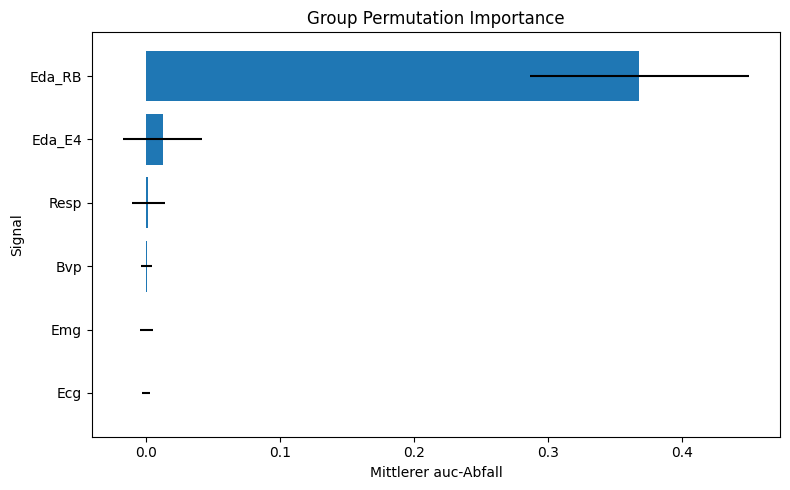

In [10]:
signal_summary = metrics["group_importance"].sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    signal_summary["signal"],
    signal_summary["importance_mean"],
    xerr=signal_summary["importance_std"]
)
plt.xlabel("Mittlerer auc-Abfall")
plt.ylabel("Signal")
plt.title("Group Permutation Importance")
plt.tight_layout()
plt.show()

# Random Forest Signal Importance

- modell auf den einzelnen signalen trainiert
- schaue mir accuracy an

In [11]:
# get groups for each signal
feature_names = np.load(DATASET_PATH / "feature_names.npy", allow_pickle=True)
signal_groups = make_signal_groups(feature_names)

# safe resuls
all_results = []

rf = RandomForestClassifier(random_state=RANDOM_STATE)
for signal in signal_groups.keys():

    X_signal = X_comp[:, signal_groups[signal]]
    y_signal = y_binary

    print(f"Signal: {signal}")
    rf_signal = loso_binary_nested_cv(
        X_signal,
        y_signal,
        group_labels,
        rf,
        PARAM_GRID_RF,
        model_type="classifier"
    )

    all_results.append({
        "signal": signal,
        "n_features": X_signal.shape[1],
        "accuracy": rf_signal["accuracy"],
        "accuracy_std": rf_signal["accuracy_std"],
        "auc": rf_signal["auc"],
        "auc_std": rf_signal["auc_std"],
        "f1": rf_signal["f1"],
        "f1_std": rf_signal["f1_std"],
        "sensitivity": rf_signal["sensitivity"],
        "sensitivity_std": rf_signal["sensitivity_std"],
        "specificity": rf_signal["specificity"],
        "specificity_std": rf_signal["specificity_std"],
    })
        
    print(f"    Accuracy : {rf_signal['accuracy']:.3f} ± {rf_signal['accuracy_std']:.3f}")
    print(f"    AUC      : {rf_signal['auc']:.3f} ± {rf_signal['auc_std']:.3f}")
    print(f"    F1       : {rf_signal['f1']:.3f} ± {rf_signal['f1_std']:.3f}")
    print(f"    Sensitivity : {rf_signal['sensitivity']:.3f} ± {rf_signal['sensitivity_std']:.3f}")
    print(f"    Specificity : {rf_signal['specificity']:.3f} ± {rf_signal['specificity_std']:.3f}")

results_df = pd.DataFrame(all_results)
results_df.to_csv("signal_specific_results.csv", index=False)

Signal: Bvp
    Accuracy : 0.649 ± 0.132
    AUC      : 0.708 ± 0.171
    F1       : 0.624 ± 0.166
    Sensitivity : 0.630 ± 0.248
    Specificity : 0.668 ± 0.271
Signal: Ecg
    Accuracy : 0.719 ± 0.127
    AUC      : 0.782 ± 0.138
    F1       : 0.685 ± 0.198
    Sensitivity : 0.695 ± 0.266
    Specificity : 0.743 ± 0.217
Signal: Eda_E4
    Accuracy : 0.825 ± 0.124
    AUC      : 0.903 ± 0.109
    F1       : 0.805 ± 0.162
    Sensitivity : 0.794 ± 0.218
    Specificity : 0.856 ± 0.133
Signal: Eda_RB
    Accuracy : 0.928 ± 0.084
    AUC      : 0.980 ± 0.035
    F1       : 0.920 ± 0.110
    Sensitivity : 0.915 ± 0.151
    Specificity : 0.940 ± 0.076
Signal: Emg
    Accuracy : 0.660 ± 0.136
    AUC      : 0.773 ± 0.165
    F1       : 0.594 ± 0.243
    Sensitivity : 0.619 ± 0.339
    Specificity : 0.702 ± 0.295
Signal: Resp
    Accuracy : 0.674 ± 0.163
    AUC      : 0.734 ± 0.172
    F1       : 0.639 ± 0.216
    Sensitivity : 0.635 ± 0.270
    Specificity : 0.714 ± 0.250


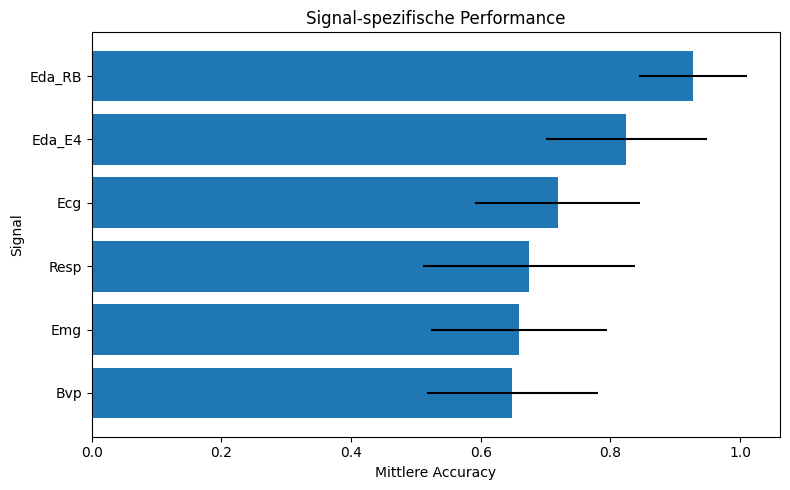

In [4]:
results_df = pd.read_csv("signal_specific_results.csv")
signal_summary = results_df.sort_values("accuracy", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    signal_summary["signal"],
    signal_summary["accuracy"],
    xerr=signal_summary["accuracy_std"]
)

plt.xlabel("Mittlere Accuracy")
plt.ylabel("Signal")
plt.title("Signal-spezifische Performance")
plt.tight_layout()
plt.show()